In [42]:
# Install Required Libraries

!pip install pandas scikit-learn numpy xgboost

In [26]:
# Import libraries

import pandas as pd
import numpy as np

# from sklearn.feature_extraction.text import TfidfVectorizer

# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report

In [27]:
data = pd.read_csv(r"/content/drive/MyDrive/DATA FOR COLLAB/Password Strength.csv", on_bad_lines='skip')

In [28]:
data.head(25)

,password,strength
0,kzde5577,1
1,kino3434,1
2,visi7k1yr,1
3,megzy123,1
4,lamborghin1,1
5,AVYq1lDE4MgAZfNt,2
6,u6c8vhow,1
7,v1118714,1
8,universe2908,1
9,as326159,1


In [29]:
data.shape

(669640, 2)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669640 entries, 0 to 669639
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   password  669639 non-null  object
 1   strength  669640 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 10.2+ MB


In [31]:
data.isnull().sum()

,0
password,1
strength,0


In [32]:
data = data.dropna()

In [33]:
data.duplicated().sum()

np.int64(0)

In [34]:
data.head()

,password,strength
0,kzde5577,1
1,kino3434,1
2,visi7k1yr,1
3,megzy123,1
4,lamborghin1,1


In [35]:
data["strength"].value_counts()

,count
strength,
1,496801
0,89701
2,83137


<Axes: xlabel='strength', ylabel='count'>

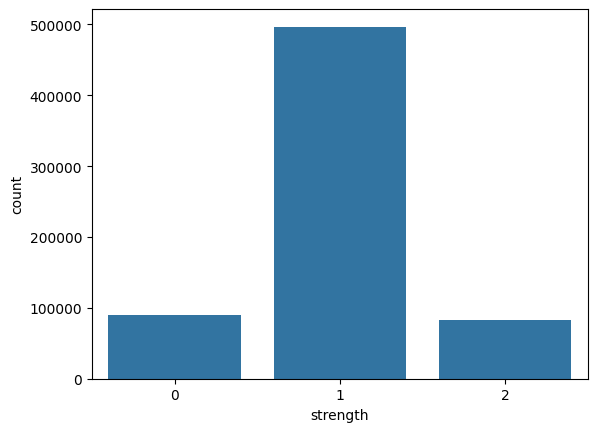

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x = 'strength', data = data)

In [37]:
# Select Features and Target

X = data['password']
y = data['strength']

In [38]:
# Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [39]:
# X_train → passwords for training
# X_test  → passwords for testing

# y_train → labels for training
# y_test  → labels for testing

In [40]:
# Import TF-IDF Vectorizer to convert text into numerical features
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a TF-IDF vectorizer using character-level analysis
vectorizer = TfidfVectorizer(analyzer='char')

# Learn the vocabulary from the training data and transform it into a TF-IDF feature matrix
X_train = vectorizer.fit_transform(X_train)

In [43]:
# Model Training

from xgboost import XGBClassifier

model_xg = XGBClassifier()

model_xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [45]:
y_pred_xg = model_xg.predict(vectorizer.transform(X_test))

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_score(y_test, y_pred_xg)

0.9799817812556

In [51]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xg))


Confusion Matrix:
[[16807  1133     0]
 [  640 98402   318]
 [    5   585 16038]]


In [52]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     17940
           1       0.98      0.99      0.99     99360
           2       0.98      0.96      0.97     16628

    accuracy                           0.98    133928
   macro avg       0.98      0.96      0.97    133928
weighted avg       0.98      0.98      0.98    133928



In [53]:
# Save model

import pickle

pickle.dump(model_xg, open("password_strength_predication.pkl", "wb"))

print("Model saved successfully")

Model saved successfully
